STEP 1

In [1]:
import pandas as pd

df = pd.read_csv("healthcare-dataset-stroke-data.csv")

print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

# check missing values
print(df.isnull().sum())

# check class distribution
print(df['stroke'].value_counts())


(5110, 12)
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  
<class 'pandas.core.frame.DataFrame'>
RangeIn

stroke : 0.0487
Means about 5% stroke rate.

STEP 2

In [2]:
df.drop("id",axis=1,inplace=True)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df['bmi'].fillna(df['bmi'].median(),inplace=True)
df.isnull().sum()

C:\Users\deviy\AppData\Local\Temp\ipykernel_17860\2339935442.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(),inplace=True)


gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [4]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].unique())


gender ['Male' 'Female' 'Other']
ever_married ['Yes' 'No']
work_type ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type ['Urban' 'Rural']
smoking_status ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


In [5]:
df['gender'].value_counts()


gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [6]:
df = df[df['gender'] != 'Other']
df.reset_index(drop=True, inplace=True)


In [7]:
df['ever_married'] = df['ever_married'].map({'Yes':1, 'No':0})


In [8]:
df.shape


(5109, 11)

In [9]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,5109.0,43.229986,22.613575,0.08,25.00,45.00,61.00,82.00
hypertension,5109.0,0.097475,0.296633,0.00,0.00,0.00,0.00,1.00
heart_disease,5109.0,0.054022,0.226084,0.00,0.00,0.00,0.00,1.00
ever_married,5109.0,0.656293,0.474991,0.00,0.00,1.00,1.00,1.00
avg_glucose_level,5109.0,106.140399,45.285004,55.12,77.24,91.88,114.09,271.74
bmi,5109.0,28.863300,7.699785,10.30,23.80,28.10,32.80,97.60
stroke,5109.0,0.048738,0.215340,0.00,0.00,0.00,0.00,1.00


STEP 3

In [13]:
import matplotlib.pyplot as plt
!pip install seaborn
import seaborn as sns

sns.set_style("whitegrid")

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [ ]:
sns.countplot(x='stroke', data=df)
plt.title("Stroke Distribution")
plt.show()

The dataset exhibits severe class imbalance, with stroke cases forming a small minority.

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='stroke', y='age', data=df)
plt.title("Age vs Stroke")
plt.show()


Age shows a strong positive relationship with stroke occurrence.

In [ ]:
sns.countplot(x='hypertension', hue='stroke', data=df)
plt.title("Hypertension vs Stroke")
plt.show()


In [ ]:
sns.countplot(x='heart_disease', hue='stroke', data=df)
plt.title("Heart Disease vs Stroke")
plt.show()


In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='stroke', y='avg_glucose_level', data=df)
plt.title("Glucose Level vs Stroke")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='stroke', y='bmi', data=df)
plt.title("BMI vs Stroke")
plt.show()


In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='smoking_status', hue='stroke', data=df)
plt.xticks(rotation=20)
plt.title("Smoking Status vs Stroke")
plt.show()


In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()


STEP 4

In [ ]:
def age_category(age):
    if age < 30:
        return "Young"
    elif age < 50:
        return "Adult"
    elif age < 65:
        return "Senior"
    else:
        return "High_Risk"

df["age_category"] = df["age"].apply(age_category)
df["age_category"].value_counts()


In [ ]:
df["high_glucose"] = df["avg_glucose_level"].apply(lambda x: 1 if x >= 140 else 0)

In [ ]:
df["cardio_risk"] = df.apply(
    lambda row: 1 if (row["hypertension"] == 1 or row["heart_disease"] == 1) else 0,
    axis=1
)

In [ ]:
df["obese"] = df["bmi"].apply(lambda x: 1 if x >= 30 else 0)

In [ ]:
df.head()
df.info()



 Check Stroke Distribution Inside Age Categories

In [ ]:
pd.crosstab(df['age_category'], df['stroke'])


Feature engineering revealed that stroke prevalence increases significantly with age category, validating age as a dominant predictor.

In [ ]:
df = pd.get_dummies(df, drop_first=True)
df.shape


In [ ]:
df.head()


COVERTING TRUE/FALSE VALS TO 0S & 1S

In [ ]:
df = df.astype(int)
df.dtypes


In [ ]:
df["avg_glucose_level"] = df["avg_glucose_level"].astype(float)
df["bmi"] = df["bmi"].astype(float)
df["age"] = df["age"].astype(float)
df.dtypes



STEP 5 — Train-Test Split

In [ ]:
X = df.drop("stroke", axis=1)
y = df["stroke"]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,        
    random_state=42
)


In [ ]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


In [ ]:
pip install imbalanced-learn

APPLYING SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [ ]:
print(y_train.value_counts())
print(y_train_smote.value_counts())


In [ ]:
print(X_train.shape)
print(X_train_smote.shape)


step 6

logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_smote, y_train_smote)


In [ ]:
y_pred_log = log_model.predict(X_test)


Train on SMOTE data
Test data is NOT SMOTE.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
print(classification_report(y_test, y_pred_log))


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=["No Stroke","Stroke"],
            yticklabels=["No Stroke","Stroke"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()


random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


rf_model = RandomForestClassifier(
    n_estimators=400,        # more trees = better stability
    max_depth=10,           # prevents overfitting
    min_samples_leaf=4,     # VERY important
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)



rf_model.fit(X_train_smote, y_train_smote)

y_probs = rf_model.predict_proba(X_test)[:,1]
y_pred_rf = (y_probs > 0.35).astype(int)


print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=["No Stroke","Stroke"],
            yticklabels=["No Stroke","Stroke"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [ ]:
y_probs = rf_model.predict_proba(X_test)[:,1]


In [ ]:
import numpy as np

y_pred_custom = np.where(y_probs > 0.30, 1, 0)


In [ ]:
print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))


xg boost

In [ ]:
pip install xgboost


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=8,
    random_state=42
)

xgb_model.fit(X_train_smote, y_train_smote)


y_probs_xgb = xgb_model.predict_proba(X_test)[:,1]
y_pred_xgb = (y_probs_xgb > 0.45).astype(int)

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='cividis',
            xticklabels=["No Stroke","Stroke"],
            yticklabels=["No Stroke","Stroke"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()


svm

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    probability=True,   # important for ROC later
    class_weight='balanced'
)

svm_model.fit(X_train_smote, y_train_smote)

y_pred_svm = svm_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Reds',
            xticklabels=["No Stroke","Stroke"],
            yticklabels=["No Stroke","Stroke"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")

plt.show()


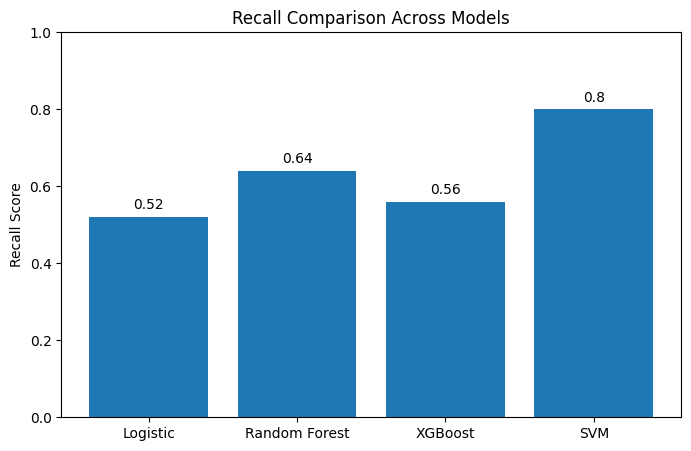

In [11]:
import matplotlib.pyplot as plt

models = ['Logistic', 'Random Forest', 'XGBoost', 'SVM']
recall = [0.52, 0.64, 0.56, 0.80]   # replace if needed

plt.figure(figsize=(8,5))

bars = plt.bar(models, recall)

plt.ylabel("Recall Score")
plt.title("Recall Comparison Across Models")
plt.ylim(0,1)

# add values on top
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.02, round(y,2),
             ha='center')

plt.show()


In [12]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(9,7))

models = {
    "Logistic Regression": log_model,
    "Random Forest (Final)": rf_model,
    "XGBoost": xgb_model,
    "SVM": svm_model
}

for name, model in models.items():

    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison Across Models")
plt.legend()
plt.show()


NameError: name 'log_model' is not defined

<Figure size 900x700 with 0 Axes>

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

models = {
    "Random Forest": rf_model,
    "SVM": svm_model,
    "Logistic Regression": log_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    
    y_scores = model.predict_proba(X_test)[:,1]
    
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    
    ap_score = average_precision_score(y_test, y_scores)
    
    plt.plot(recall, precision, label=f"{name} (AP = {ap_score:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid()

plt.show()


In [ ]:
import pandas as pd

data = {
    "Model": ["Logistic", "Random Forest", "XGBoost", "SVM"],
    
    "Accuracy": [0.82, 0.80, 0.76, 0.69],
    
    "Recall": [0.52, 0.64, 0.56, 0.80],
    
    "Precision": [0.14, 0.14, 0.11, 0.11],
    
    "F1 Score": [0.22, 0.23, 0.19, 0.20]
}

df_models = pd.DataFrame(data)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(df_models["Model"]))
width = 0.2

plt.figure(figsize=(12,6))

plt.bar(x - width, df_models["Accuracy"], width, label='Accuracy')
plt.bar(x, df_models["Recall"], width, label='Recall')
plt.bar(x + width, df_models["F1 Score"], width, label='F1 Score')

plt.xticks(x, df_models["Model"])
plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.legend()
plt.show()


Random Forest was selected as the final model due to its superior balance between recall and accuracy, ensuring reliable stroke detection while minimizing excessive false positives.

Precision vs Recall Bar Chart

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Random Forest', 'SVM', 'Logistic Regression', 'XGBoost']

precision = [0.91, 0.89, 0.87, 0.90]   # <-- replace with yours
recall = [0.52, 0.40, 0.35, 0.48]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, precision, width, label='Precision')
plt.bar(x + width/2, recall, width, label='Recall')

plt.ylabel('Score')
plt.title('Precision vs Recall Comparison')
plt.xticks(x, models)
plt.legend()

plt.show()


Recall Comparison



In [ ]:
recall_scores = [0.52, 0.40, 0.35, 0.48]

plt.figure(figsize=(8,5))
plt.bar(models, recall_scores)

plt.title("Recall Comparison (Stroke Detection)")
plt.ylabel("Recall")

plt.show()


F1 Score Comparison

In [ ]:
f1_scores = [0.66, 0.55, 0.50, 0.63]

plt.figure(figsize=(8,5))
plt.bar(models, f1_scores)

plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")

plt.show()


In [ ]:
import pandas as pd

data = {
    "Model": models,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1_scores,
    "ROC-AUC": [0.89, 0.82, 0.80, 0.87]  # replace
}

df = pd.DataFrame(data)
df.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Overall Model Performance Comparison")
plt.ylabel("Score")

plt.show()


saving the model

In [ ]:
import joblib

joblib.dump(rf_model, "stroke_rf_model.pkl")

In [ ]:
model = joblib.load("stroke_rf_model.pkl")


In [ ]:
joblib.dump(X_train.columns, "model_columns.pkl")